# Importar datos

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
ruta = "/content/drive/MyDrive/001 - FIC 24092023 al 30092025 (Mod).xlsx"
df = pd.read_excel(ruta)

Mounted at /content/drive


In [ ]:
df.head()

,Fecha corte,Administradora,Categoría,Fondo,Valor Unidad,Rentabilidad Día,Rentabilidad Mes,Rentabilidad Semestral,Rentabilidad Anual,Volatilidad Mes,Volatilidad Semestral,Volatilidad Anual
0,2023-09-24,BBVA,FIS,Páramo,10902.22,11.278044,16.146566,19.697256,19.278606,5.118603,4.630033,5.629336
1,2023-09-24,BBVA,FIC,FAM,3008.47,11.164635,20.832920,12.413018,14.920787,1.695836,0.826005,0.804279
2,2023-09-24,Corficolombiana,FIS,Sostenible Global,27818.23,-1.542250,-42.209785,-22.444342,3.533033,10.203745,13.636394,16.963866
3,2023-09-24,Corficolombiana,FIC,Valor Plus I,44428.62,10.703372,20.299822,10.920641,14.046575,1.262626,0.606991,0.705028
4,2023-09-25,BBVA,FIS,Páramo,10837.34,-88.678140,7.611409,18.213993,18.527777,5.413398,4.718182,5.666023


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2784 entries, 0 to 2783
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Fecha corte             2784 non-null   object 
 1   Administradora          2784 non-null   object 
 2   Categoría               2784 non-null   object 
 3   Fondo                   2784 non-null   object 
 4   Valor Unidad            2784 non-null   float64
 5   Rentabilidad Día        2784 non-null   float64
 6   Rentabilidad Mes        2784 non-null   float64
 7   Rentabilidad Semestral  2784 non-null   float64
 8   Rentabilidad Anual      2784 non-null   float64
 9   Volatilidad Mes         2784 non-null   float64
 10  Volatilidad Semestral   2784 non-null   float64
 11  Volatilidad Anual       2784 non-null   float64
dtypes: float64(8), object(4)
memory usage: 261.1+ KB


Calcula los retornos logaritmicos por cada fondo

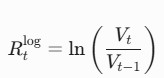

In [ ]:
import pandas as pd
import numpy as np

def calcular_retornos_todos_los_fondos(df):
    """
    Itera sobre cada fondo único en el DataFrame, calcula sus retornos
    logarítmicos de forma aislada y retorna un DataFrame unificado.
    """
    print("Iniciando procesamiento por fondo...")

    # 1. Asegurarnos de que la fecha sea tipo datetime
    df['Fecha corte'] = pd.to_datetime(df['Fecha corte'])

    # 2. Lista vacía para ir guardando los pedazos procesados
    lista_fondos_procesados = []

    # 3. Obtener la lista exacta de fondos únicos (tu ciclo for)
    fondos_unicos = df['Fondo'].unique()

    for fondo in fondos_unicos:
        # Filtrar solo la información de este fondo específico
        df_temp = df[df['Fondo'] == fondo].copy()

        # Ordenar cronológicamente (vital para que el shift funcione bien)
        df_temp = df_temp.sort_values(by='Fecha corte')

        # Calcular el Retorno Logarítmico Nominal
        df_temp['Retorno_Log'] = np.log(df_temp['Valor Unidad'] / df_temp['Valor Unidad'].shift(1))

        # Opcional: configurar la fecha como índice si tus modelos lo piden luego
        # df_temp.set_index('Fecha corte', inplace=True)

        # Guardar el bloque procesado en nuestra lista
        lista_fondos_procesados.append(df_temp)

        print(f"Fondo procesado: {fondo} | Registros: {len(df_temp)}")

    # 4. Unir todos los fondos ya procesados en un solo DataFrame maestro
    df_final = pd.concat(lista_fondos_procesados)

    # 5. Limpiar los nulos (el primer día histórico de CADA fondo quedará como NaN)
    df_final = df_final.dropna(subset=['Retorno_Log'])

    print(f"\n¡Proceso terminado! Total de registros limpios: {len(df_final)}")

    return df_final

In [ ]:
# 1. Ejecutar la función pasándole tu DataFrame original y guardar el resultado
df_resultados = calcular_retornos_todos_los_fondos(df)

# 2. Mostrar las primeras 5 filas en pantalla para visualizar la nueva columna
df_resultados.head()

Iniciando procesamiento por fondo...
Fondo procesado: Páramo | Registros: 726
Fondo procesado: FAM | Registros: 730
Fondo procesado: Sostenible Global | Registros: 662
Fondo procesado: Valor Plus I | Registros: 666

¡Proceso terminado! Total de registros limpios: 2780


,Fecha corte,Administradora,Categoría,Fondo,Valor Unidad,Rentabilidad Día,Rentabilidad Mes,Rentabilidad Semestral,Rentabilidad Anual,Volatilidad Mes,Volatilidad Semestral,Volatilidad Anual,Retorno_Log
4,2023-09-25,BBVA,FIS,Páramo,10837.34,-88.678140,7.611409,18.213993,18.527777,5.413398,4.718182,5.666023,-0.005969
8,2023-09-26,BBVA,FIS,Páramo,10791.02,-79.063965,1.769775,17.140326,18.359790,5.627244,4.765064,5.676106,-0.004283
12,2023-09-27,BBVA,FIS,Páramo,10733.54,-85.760340,-7.655409,15.686071,17.638214,5.921590,4.833077,5.705498,-0.005341
16,2023-09-28,BBVA,FIS,Páramo,10724.86,-25.581083,-18.005445,15.684179,17.627235,5.842990,4.833120,5.705696,-0.000809
20,2023-09-29,BBVA,FIS,Páramo,10774.17,433.568700,-16.208685,16.222439,18.403833,5.150652,4.862246,5.715469,0.004587


In [ ]:
df_resultados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2780 entries, 4 to 2717
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Fecha corte             2780 non-null   datetime64[ns]
 1   Administradora          2780 non-null   object        
 2   Categoría               2780 non-null   object        
 3   Fondo                   2780 non-null   object        
 4   Valor Unidad            2780 non-null   float64       
 5   Rentabilidad Día        2780 non-null   float64       
 6   Rentabilidad Mes        2780 non-null   float64       
 7   Rentabilidad Semestral  2780 non-null   float64       
 8   Rentabilidad Anual      2780 non-null   float64       
 9   Volatilidad Mes         2780 non-null   float64       
 10  Volatilidad Semestral   2780 non-null   float64       
 11  Volatilidad Anual       2780 non-null   float64       
 12  Retorno_Log             2780 non-null   float64      

# Pruebas de estacionariedad

Prueba ADF (Augmented Dickey-Fuller):

Es paramétrica. Para lidiar con la autocorrelación (el hecho de que lo que pasa hoy en el fondo depende de lo que pasó ayer), la prueba ADF agrega rezagos de la misma variable en su ecuación. Asume que la varianza del error es constante

In [ ]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def evaluar_estacionariedad_adf(df, columna_objetivo='Valor Unidad'):
    """
    Aplica la prueba ADF a una columna específica por cada fondo único.
    """
    resultados = []

    # Iteramos sobre cada fondo único
    fondos_unicos = df['Fondo'].unique()

    for fondo in fondos_unicos:
        # Filtramos y limpiamos la serie (quitamos NaNs para que la prueba no falle)
        serie = df[df['Fondo'] == fondo][columna_objetivo].dropna()

        # Aplicamos la prueba ADF
        # autolag='AIC' elige automáticamente el número de rezagos óptimo
        adf_test = adfuller(serie, autolag='AIC')
        p_valor = adf_test[1]

        # Lógica de decisión
        es_estacionaria = p_valor < 0.05
        tiene_raiz_unitaria = not es_estacionaria

        # Guardamos resultados
        resultados.append({
            'Fondo': fondo,
            'p_valor': round(p_valor, 5),
            'Es_Estacionaria': 'Sí' if es_estacionaria else 'No',
            'Tiene_Raiz_Unitaria': 'Sí' if tiene_raiz_unitaria else 'No'
        })

    # Convertimos a DataFrame para una visualización limpia
    df_resultados = pd.DataFrame(resultados)
    return df_resultados

# ==========================================
tabla_adf = evaluar_estacionariedad_adf(df, 'Valor Unidad')

# Mostrar la tabla final
print("Prueba ADF por fondo serie -Valor Unidad-")
print(tabla_adf)

Prueba ADF por fondo serie -Valor Unidad-
               Fondo  p_valor Es_Estacionaria Tiene_Raiz_Unitaria
0             Páramo  0.59861              No                  Sí
1                FAM  0.39595              No                  Sí
2  Sostenible Global  0.33491              No                  Sí
3       Valor Plus I  0.42379              No                  Sí


La prueba ADF confirmó la presencia de raíz unitaria en la serie de 'Valor Unidad' ($p > 0.05$), validando estadísticamente su no estacionariedad. Esta evidencia justifica metodológicamente la aplicación de la transformación logarítmica para estabilizar la serie como requisito previo al modelado econométrico.

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

def evaluar_estacionariedad_adf(df, columna_objetivo):
    """
    Aplica la prueba ADF a una columna específica por cada fondo único.
    """
    resultados = []

    # Asegurarnos de que existen los fondos
    fondos_unicos = df['Fondo'].unique()

    for fondo in fondos_unicos:
        # Filtramos la serie y eliminamos NaNs (necesario para la prueba)
        serie = df[df['Fondo'] == fondo][columna_objetivo].dropna()

        # Aplicamos la prueba ADF
        # autolag='AIC' determina el número de rezagos óptimo
        adf_test = adfuller(serie, autolag='AIC')
        p_valor = adf_test[1]

        # Lógica de decisión académica
        es_estacionaria = p_valor < 0.05
        tiene_raiz_unitaria = not es_estacionaria

        resultados.append({
            'Fondo': fondo,
            'p_valor': round(p_valor, 5),
            'Es_Estacionaria': 'Sí' if es_estacionaria else 'No',
            'Tiene_Raiz_Unitaria': 'Sí' if tiene_raiz_unitaria else 'No'
        })

    return pd.DataFrame(resultados)

# ==========================================
# EJECUCIÓN FINAL PARA RETORNOS LOGARÍTMICOS
# ==========================================
# Ejecutamos la función sobre la columna de retornos que ya calculamos
tabla_adf_retornos = evaluar_estacionariedad_adf(df_resultados, 'Retorno_Log')

# Mostrar la tabla resultante
print("--- Resultados ADF: Retorno Logarítmico ---")
print(tabla_adf_retornos)

--- Resultados ADF: Retorno Logarítmico ---
               Fondo  p_valor Es_Estacionaria Tiene_Raiz_Unitaria
0             Páramo      0.0              Sí                  No
1                FAM      0.0              Sí                  No
2  Sostenible Global      0.0              Sí                  No
3       Valor Plus I      0.0              Sí                  No


Los resultados de la prueba ADF aplicados a la serie de retornos logarítmicos arrojaron un p-valor de 0.000 para todos los fondos analizados. Este resultado permite rechazar contundentemente la hipótesis nula de raíz unitaria ($p < 0.05$), confirmando la estacionariedad de las series. Por consiguiente, los datos cumplen con el requisito de invarianza en el tiempo necesario para la estimación robusta de modelos ARIMA y GARCH

Prueba PP (Phillips-Perron):

Es no paramétrica. En lugar de agregar rezagos, utiliza un ajuste matemático más sofisticado sobre los errores. Es especialmente útil en finanzas porque es muy robusta frente a la heterocedasticidad (cambios bruscos de volatilidad). Dado que tus fondos seguramente tendrán periodos de alta volatilidad (lo cual modelarás con GARCH), la prueba PP suele ser más confiable que la ADF para este tipo de datos.

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 25.2 MB/s eta 0:00:00


In [ ]:
from arch.unitroot import PhillipsPerron
import pandas as pd

def evaluar_estacionariedad_pp(df, columna_objetivo='Valor Unidad'):
    """
    Aplica la prueba Phillips-Perron (PP) a una columna específica por cada fondo.
    """
    resultados = []
    fondos_unicos = df['Fondo'].unique()

    for fondo in fondos_unicos:
        # Filtramos la serie y eliminamos NaNs
        serie = df[df['Fondo'] == fondo][columna_objetivo].dropna()

        # Aplicamos la prueba Phillips-Perron
        pp_test = PhillipsPerron(serie)
        p_valor = pp_test.pvalue

        # Lógica de decisión
        es_estacionaria = p_valor < 0.05
        tiene_raiz_unitaria = not es_estacionaria

        resultados.append({
            'Fondo': fondo,
            'p_valor_PP': round(p_valor, 5),
            'Es_Estacionaria': 'Sí' if es_estacionaria else 'No',
            'Tiene_Raiz_Unitaria': 'Sí' if tiene_raiz_unitaria else 'No'
        })

    return pd.DataFrame(resultados)

# ==========================================
# EJECUCIÓN
# ==========================================
tabla_pp_valor = evaluar_estacionariedad_pp(df_resultados, 'Valor Unidad')

print("--- Resultados Phillips-Perron: Valor Unidad ---")
print(tabla_pp_valor)

--- Resultados Phillips-Perron: Valor Unidad ---
               Fondo  p_valor_PP Es_Estacionaria Tiene_Raiz_Unitaria
0             Páramo     0.62328              No                  Sí
1                FAM     0.49474              No                  Sí
2  Sostenible Global     0.49935              No                  Sí
3       Valor Plus I     0.54977              No                  Sí


La robustez de los hallazgos fue verificada mediante la prueba de Phillips-Perron (PP), la cual, al ser una prueba no paramétrica, complementa el análisis de la prueba ADF al ser insensible a la heterocedasticidad. La convergencia de ambos resultados, indicando la presencia de raíz unitaria en los niveles de precios para todos los fondos analizados ($p > 0.05$), ratifica de manera concluyente la necesidad de la transformación a retornos logarítmicos como paso previo indispensable para el modelado econométrico.

In [ ]:
from arch.unitroot import PhillipsPerron
import pandas as pd

def evaluar_estacionariedad_pp(df, columna_objetivo='Retorno_Log'):
    """
    Aplica la prueba Phillips-Perron (PP) a una columna específica por cada fondo.
    """
    resultados = []
    fondos_unicos = df['Fondo'].unique()

    for fondo in fondos_unicos:
        # Filtramos la serie y eliminamos NaNs
        serie = df[df['Fondo'] == fondo][columna_objetivo].dropna()

        # Aplicamos la prueba Phillips-Perron
        pp_test = PhillipsPerron(serie)
        p_valor = pp_test.pvalue

        # Lógica de decisión
        es_estacionaria = p_valor < 0.05
        tiene_raiz_unitaria = not es_estacionaria

        resultados.append({
            'Fondo': fondo,
            'p_valor_PP': round(p_valor, 5),
            'Es_Estacionaria': 'Sí' if es_estacionaria else 'No',
            'Tiene_Raiz_Unitaria': 'Sí' if tiene_raiz_unitaria else 'No'
        })

    return pd.DataFrame(resultados)

# ==========================================
# EJECUCIÓN
# ==========================================
tabla_pp_valor = evaluar_estacionariedad_pp(df_resultados, 'Retorno_Log')

print("--- Resultados Phillips-Perron: Retorno_Log ---")
print(tabla_pp_valor)

--- Resultados Phillips-Perron: Retorno_Log ---
               Fondo  p_valor_PP Es_Estacionaria Tiene_Raiz_Unitaria
0             Páramo         0.0              Sí                  No
1                FAM         0.0              Sí                  No
2  Sostenible Global         0.0              Sí                  No
3       Valor Plus I         0.0              Sí                  No


Esta prueba confirmó que las rentabilidades de los fondos son estables y se comportan de manera consistente en el tiempo. Este hallazgo representa un avance fundamental para la investigación, pues asegura que los datos sean confiables y carezcan de tendencias inesperadas, permitiendo así una mayor precisión en las predicciones

Se realizaron estas dos pruebas para verificar la correcta preparación de la información. Inicialmente, se comprobó que el precio original de los fondos presentaba una inestabilidad que dificultaba las predicciones; no obstante, al realizar la transformación a 'rentabilidad', los resultados demostraron que las series cuentan con un orden claro y estable. Este análisis valida la metodología aplicada y brinda seguridad sobre el funcionamiento profesional del modelo matemático

# Pruebas de autocorrelación

Los autocorrelogramas son representaciones gráficas que permiten identificar qué tan relacionada está una serie consigo misma en diferentes momentos del pasado (rezagos o lags).

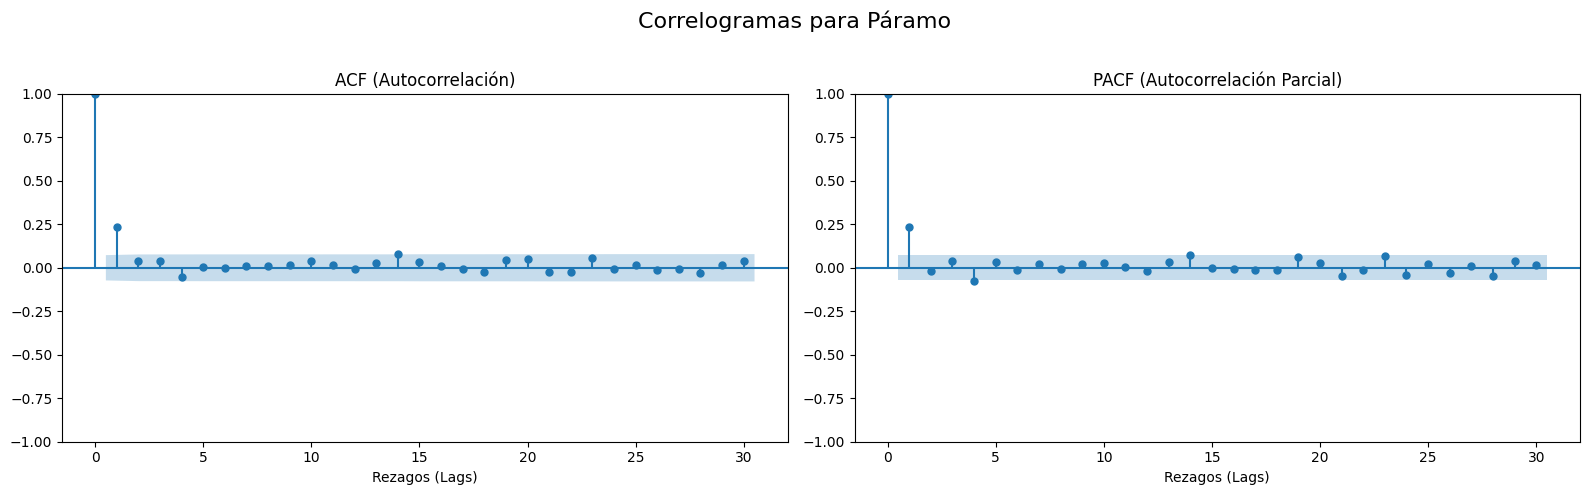

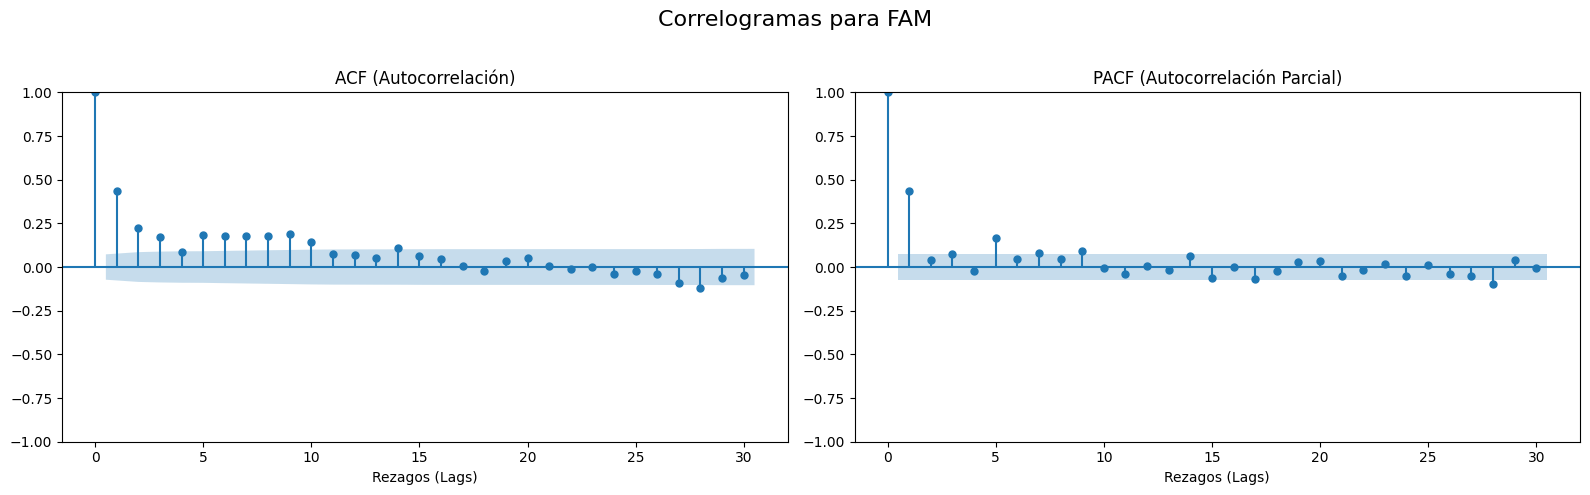

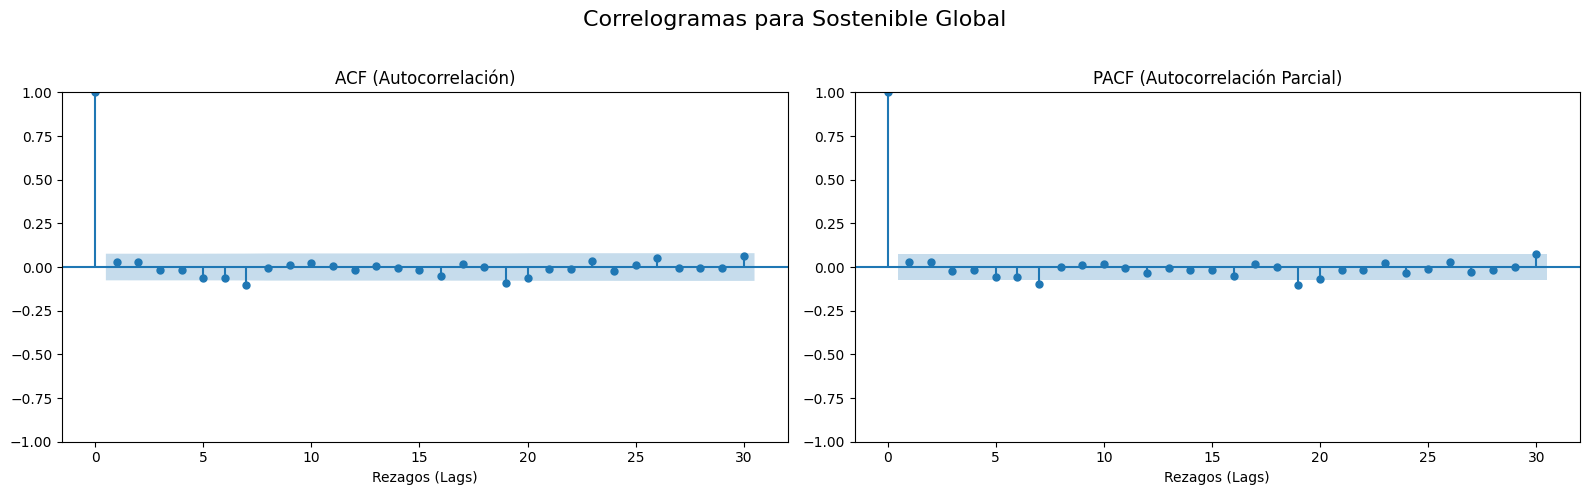

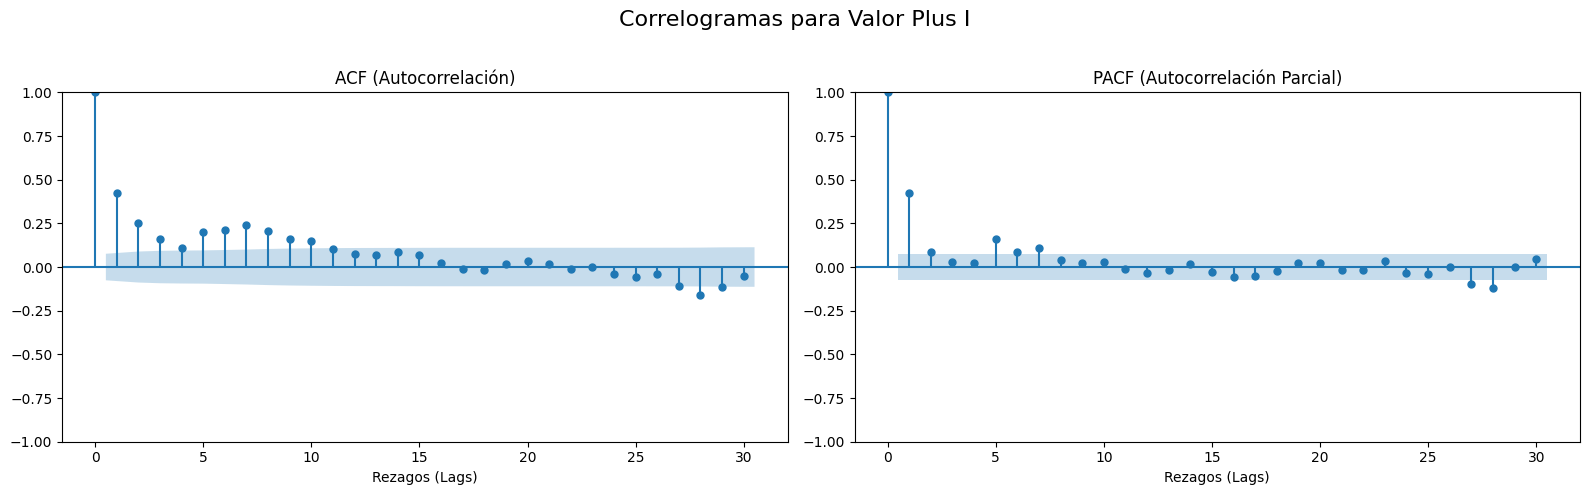

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def generar_correlogramas(df, columna='Retorno_Log', lags=30):
    fondos = df['Fondo'].unique()

    for fondo in fondos:
        # Filtramos por fondo
        serie = df[df['Fondo'] == fondo][columna].dropna()

        # Generar figuras
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle(f'Correlogramas para {fondo}', fontsize=16)

        # ACF (Media móvil)
        plot_acf(serie, ax=axes[0], lags=lags, title='ACF (Autocorrelación)')
        axes[0].set_xlabel('Rezagos (Lags)')

        # PACF (Autoregresión)
        plot_pacf(serie, ax=axes[1], lags=lags, title='PACF (Autocorrelación Parcial)', method='ywm')
        axes[1].set_xlabel('Rezagos (Lags)')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

# Ejecución
generar_correlogramas(df_resultados)

El análisis de los correlogramas ACF y PACF reveló comportamientos diferenciados en la estructura de dependencia temporal de los fondos. Mientras que FAM y Valor Plus I exhibieron un comportamiento autorregresivo predominante, Páramo y Sostenible Global mostraron una estructura cercana al ruido blanco.

La prueba de Ljung-Box

Es un test estadístico que complementa a los gráficos anteriores. A diferencia de los gráficos, esta prueba da un resultado numérico (un p-valor) para confirmar si existe autocorrelación significativa en la serie.

Se basa en una hipótesis nula ($H_0$) que dicta que los datos son independientes y no tienen estructura (son "ruido blanco").

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd

def evaluar_ljung_box(df, columna='Retorno_Log', lags=10):
    """
    Aplica la prueba de Ljung-Box a cada fondo.
    """
    fondos = df['Fondo'].unique()
    resultados_lb = []

    for fondo in fondos:
        serie = df[df['Fondo'] == fondo][columna].dropna()

        # Aplicación de la prueba
        # Se toma el resultado para el lag 10 como referencia estándar
        lb_test = acorr_ljungbox(serie, lags=[lags], return_df=True)
        p_valor = lb_test['lb_pvalue'].values[0]

        resultados_lb.append({
            'Fondo': fondo,
            'p_valor_LB': round(p_valor, 5),
            '¿Tiene Autocorrelación?': 'Sí' if p_valor < 0.05 else 'No'
        })

    return pd.DataFrame(resultados_lb)

# Ejecución
df_ljung_box = evaluar_ljung_box(df_resultados)
print(df_ljung_box)

               Fondo  p_valor_LB ¿Tiene Autocorrelación?
0             Páramo     0.00000                      Sí
1                FAM     0.00000                      Sí
2  Sostenible Global     0.17014                      No
3       Valor Plus I     0.00000                      Sí


La aplicación de la prueba de Ljung-Box sobre la serie de retornos logarítmicos permitió determinar la presencia de estructura temporal en los activos. Para los fondos Páramo, FAM y Valor Plus I, se identificó una dependencia temporal estadísticamente significativa ($p < 0.05$), lo que justifica el empleo de modelos autorregresivos. En contraste, el fondo Sostenible Global exhibió un comportamiento coherente con la hipótesis de paseo aleatorio ($p > 0.05$), lo cual sugiere una ausencia de memoria predictiva lineal y limita la capacidad explicativa de los modelos ARIMA tradicionales para este activo específico

# Pruebas de normalidad

En el análisis de series de tiempo financieras, se requiere conocer la distribución de los residuos. Si los residuos son normales, los intervalos de confianza del modelo ARIMA son más precisos. Sin embargo, en finanzas es extremadamente común encontrar que los retornos no siguen una distribución normal (fenómeno conocido como leptocurtosis o colas pesadas).

Prueba de Jarque-Bera (JB):

Es la prueba estándar en econometría financiera. Compara la asimetría (skewness) y la curtosis (kurtosis) de la serie con las de una distribución normal.

Ventaja: Es muy robusta para muestras grandes.

Prueba de Shapiro-Wilk (SW):

Evalúa qué tanto se aleja la distribución de los datos de una línea recta teórica.

Ventaja: Es extremadamente sensible, ideal para detectar desviaciones finas, aunque en series muy largas puede rechazar la normalidad incluso por variaciones minúsculas.

In [ ]:
from scipy import stats
from statsmodels.stats.stattools import jarque_bera
import pandas as pd

def evaluar_normalidad(df, columna='Retorno_Log'):
    resultados = []
    fondos = df['Fondo'].unique()

    for fondo in fondos:
        serie = df[df['Fondo'] == fondo][columna].dropna()

        # Jarque-Bera
        jb_stat, jb_p, skew, kurt = jarque_bera(serie)

        # Shapiro-Wilk
        sw_stat, sw_p = stats.shapiro(serie)

        resultados.append({
            'Fondo': fondo,
            'p_valor_JB': round(jb_p, 5),
            'Normal_JB': 'Sí' if jb_p > 0.05 else 'No',
            'p_valor_SW': round(sw_p, 5),
            'Normal_SW': 'Sí' if sw_p > 0.05 else 'No'
        })

    return pd.DataFrame(resultados)

# Ejecución
df_normalidad = evaluar_normalidad(df_resultados)
print(df_normalidad)

               Fondo  p_valor_JB Normal_JB  p_valor_SW Normal_SW
0             Páramo         0.0        No         0.0        No
1                FAM         0.0        No         0.0        No
2  Sostenible Global         0.0        No         0.0        No
3       Valor Plus I         0.0        No         0.0        No


Las pruebas de normalidad confirmaron que los retornos no siguen una distribución ideal, mostrando un comportamiento con cambios bruscos y agrupamientos de volatilidad. Este hallazgo justifica el uso de modelos GARCH, ya que son capaces de capturar y explicar estas variaciones que un modelo estándar no podría procesar adecuadamente.

Las series tienen "colas pesadas" (leptocurtosis). Los mercados financieros no se mueven bajo una "Campana de Gauss" perfecta; tienen días de ganancias o pérdidas extremas mucho más frecuentes de lo que la estadística teórica predice.